# Análisis Predictivo - Evaluación 3

El archivo que se le suministra es un conjunto de datos de pacientes con cáncer de mama se obtuvo de la actualización de noviembre de 2017 del Programa SEER del NCI, que proporciona información sobre estadísticas de cáncer basadas en la población. El conjunto de datos incluyó a pacientes de sexo femenino con cáncer de mama de carcinoma lobular y ductal infiltrante (códigos histológicos 8522/3 de recodificación NOS de citas primarias del SEER) diagnosticado entre 2006 y 2010.

Las variables que contiene este dataset son:

1. Age: Se refiere a la edad del paciente en el momento del diagnóstico.
2. Race: raza o etnia del paciente.
3. Marital Status: El estado civil del paciente (casado, soltero, divorciado, etc.).
4. T Stage: La clasificación del tamaño o extensión del tumor primario (normalmente se utiliza en el sistema TNM).
5. N Stage: Se refiere a la extensión del cáncer a los ganglios linfáticos cercanos.
6. 6th State: Puede referirse al estadio del cáncer según una clasificación específica (como la clasificación AJCC).
7. differentiate: Se refiere al grado de diferenciación celular del tumor (lo diferentes que son las células tumorales de las células normales), un factor utilizado para determinar la agresividad del cáncer.
8. Grade: Se refiere al grado de progresión del tumor o cáncer y a cuánto se ha extendido.
9. A Stage: Puede referirse a un estadio específico en la clasificación por estadios del cáncer.
10. Tumor Size: El tamaño medido del tumor primario.
11. Estrogen Status: Estado de los receptores de estrógenos en las células cancerosas (positivo o negativo), que afecta al tratamiento.
12. Progesterone Status: Estado de los receptores de progesterona en las células cancerosas (positivo o negativo).
13. Regional Node Examined: El número de ganglios linfáticos examinados para detectar la propagación del cáncer.
14. Reginol Node Positive: El número de ganglios linfáticos que dieron positivo para el cáncer.
15. Survival Monyhs: El número de meses que el paciente estuvo vivo después del diagnóstico.
16. Status: El estado final del paciente (como supervivencia o muerte).

Se creo un modelo de regresión logística para predecir la variable **Status**, con los siguientes resultados:

```
                precision    recall  f1-score   support

       Alive       0.95      0.81      0.88       678
        Dead       0.42      0.76      0.54       121

    accuracy                           0.80       799
   macro avg       0.69      0.79      0.71       799
weighted avg       0.87      0.80      0.83       799

```

# Parte 1

Haga un modelo de bosque aleatorio para predecir la variable **Status**.

Particione los datos en una proporción 80/20, haciendo `random_state=1`, y `stratify=y`.

El modelo debe ser sintonizado.

Reporte:
- El score de validación y los valores de los hiperparámetros sintonizados.
- El score de entrenamiento.
- El score de prueba.
- La matriz de confusión
- El reporte de clasificación.
- La importancia relativa de cada característica del modelo en un dataframe.

El objetivo es que el modelo supere el f1-score del modelo de regresión logísitca. Así:
- Si el f1-score obtenido es menor a 0.54, la máxima nota que obtendrá es 3.0.
- Si el f1-score obtenido es menor a 0.57, la máxima nota que obtendrá es 4.0.
- Si el f1-score obtenido es menor a 0.59, la máxima nota que obtendrá es 4.5.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Breast_Cancer_dataset.csv', sep=';')

df = df.dropna(subset=['Status'])

y = (df['Status'] == 'Dead').astype(int)
X = df.drop(columns=['Status'])

print(f"Forma del dataset: {X.shape}")
print(f"\nDistribución de clases:\n{y.value_counts().rename({0: 'Alive', 1: 'Dead'})}")

Forma del dataset: (4005, 15)

Distribución de clases:
Status
Alive    3398
Dead      607
Name: count, dtype: int64


In [3]:
cat_cols = [
    'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
    'differentiate', 'Grade', 'A Stage', 'Estrogen Status', 'Progesterone Status'
]
num_cols = [
    'Age', 'Tumor Size', 'Regional Node Examined',
    'Reginol Node Positive', 'Survival Months'
]

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipe, cat_cols),
    ('num', num_pipe, num_cols)
])

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

print(f"Tamaño entrenamiento: {X_train.shape[0]} observaciones")
print(f"Tamaño prueba:        {X_test.shape[0]} observaciones")

Tamaño entrenamiento: 3204 observaciones
Tamaño prueba:        801 observaciones


In [5]:
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(
        class_weight='balanced',
        random_state=1,
        n_jobs=-1
    ))
])

In [6]:
param_dist_rf = {
    'clf__n_estimators':   [100, 150, 200, 250, 300],
    'clf__max_depth':      [None, 10, 20],
    'clf__max_features':   ['sqrt', 'log2'],
    'clf__min_samples_leaf': [1, 2, 3, 5],
    'clf__ccp_alpha':      [0.0, 0.0001, 0.001]
}

rs_rf = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring='f1',
    cv=5,
    random_state=1,
    n_jobs=-1
)

rs_rf.fit(X_train, y_train)

print("Hiperparámetros sintonizados:")
for k, v in rs_rf.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nScore de validación (f1 - Dead): {rs_rf.best_score_:.4f}")

Hiperparámetros sintonizados:
  clf__n_estimators: 150
  clf__min_samples_leaf: 1
  clf__max_features: sqrt
  clf__max_depth: 20
  clf__ccp_alpha: 0.001

Score de validación (f1 - Dead): 0.6287


In [7]:
best_rf = rs_rf.best_estimator_

train_score_rf = best_rf.score(X_train, y_train)
test_score_rf  = best_rf.score(X_test,  y_test)

print(f"Score de entrenamiento (accuracy): {train_score_rf:.4f}")
print(f"Score de prueba        (accuracy): {test_score_rf:.4f}")

Score de entrenamiento (accuracy): 0.9385
Score de prueba        (accuracy): 0.8752


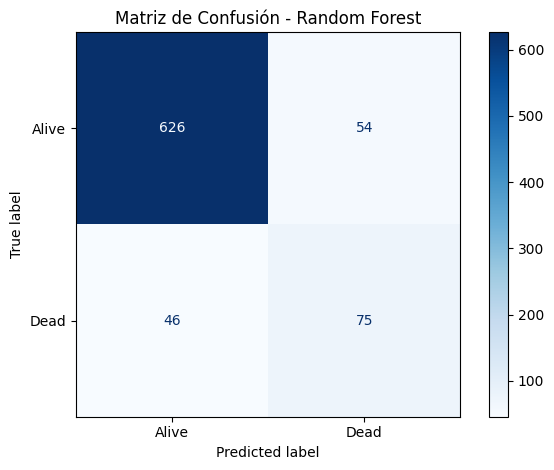

In [8]:
y_pred_rf = best_rf.predict(X_test)

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Alive', 'Dead'])
disp_rf.plot(cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.tight_layout()
plt.show()

In [9]:
print("Reporte de clasificación - Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=['Alive', 'Dead']))

Reporte de clasificación - Random Forest:
              precision    recall  f1-score   support

       Alive       0.93      0.92      0.93       680
        Dead       0.58      0.62      0.60       121

    accuracy                           0.88       801
   macro avg       0.76      0.77      0.76       801
weighted avg       0.88      0.88      0.88       801



In [10]:
feature_names = cat_cols + num_cols
importancias_rf = best_rf.named_steps['clf'].feature_importances_

df_importancias_rf = (
    pd.DataFrame({'Característica': feature_names, 'Importancia': importancias_rf})
    .sort_values('Importancia', ascending=False)
    .reset_index(drop=True)
)

print("Importancia relativa de características - Random Forest:")
display(df_importancias_rf)

Importancia relativa de características - Random Forest:


,Característica,Importancia
0,Survival Months,0.449997
1,Age,0.092405
2,Tumor Size,0.077168
3,Regional Node Examined,0.074409
4,Reginol Node Positive,0.068327
5,N Stage,0.044011
6,6th Stage,0.040434
7,Marital Status,0.027826
8,Grade,0.027257
9,Progesterone Status,0.025893


# Parte 2
 
Haga un modelo de boosting para predecir la variable **Status**.

Particione los datos en una proporción 80/20, haciendo `random_state=1`, y `stratify=y`.

El modelo debe ser sintonizado.

Reporte:
- El score de validación y los valores de los hiperparámetros sintonizados.
- El score de entrenamiento.
- El score de prueba.
- La matriz de confusión
- El reporte de clasificación.
- La importancia relativa de cada característica del modelo en un dataframe.

El objetivo es que el modelo supere el recall score del modelo de regresión logísitca. Así:
- Si el recall obtenido es menor a 0.50, la máxima nota que obtendrá es 3.0.
- Si el recall obtenido es menor a 0.60, la máxima nota que obtendrá es 4.0.
- Si el recall obtenido es menor a 0.80, la máxima nota que obtendrá es 4.5.

In [11]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import make_scorer, recall_score

In [12]:
gb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', GradientBoostingClassifier(random_state=1))
])

In [13]:
param_dist_gb = {
    'clf__n_estimators':     [100, 150, 200, 250, 300],
    'clf__learning_rate':    [0.05, 0.08, 0.1, 0.15, 0.2],
    'clf__max_depth':        [3, 4, 5],
    'clf__subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
    'clf__min_samples_leaf': [1, 3, 5, 10]
}

scorer_recall = make_scorer(recall_score, pos_label=1)

rs_gb = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=param_dist_gb,
    n_iter=20,
    scoring=scorer_recall,
    cv=5,
    random_state=1,
    n_jobs=-1
)

rs_gb.fit(X_train, y_train)

print("Hiperparámetros sintonizados:")
for k, v in rs_gb.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nScore de validación (recall - Dead): {rs_gb.best_score_:.4f}")

Hiperparámetros sintonizados:
  clf__subsample: 0.7
  clf__n_estimators: 250
  clf__min_samples_leaf: 10
  clf__max_depth: 3
  clf__learning_rate: 0.05

Score de validación (recall - Dead): 0.5268


In [14]:
from sklearn.metrics import f1_score as _f1

best_gb_pipeline = rs_gb.best_estimator_

probs_gb = best_gb_pipeline.predict_proba(X_test)[:, 1]

resultados_umbral = []
for t in np.arange(0.25, 0.55, 0.05):
    y_t = (probs_gb >= t).astype(int)
    resultados_umbral.append({
        'Umbral': round(t, 2),
        'Recall (Dead)': round(recall_score(y_test, y_t), 4),
        'F1 (Dead)':     round(_f1(y_test, y_t), 4)
    })

df_umbrales = pd.DataFrame(resultados_umbral)
print("Análisis de umbrales de decisión:")
display(df_umbrales)


umbral_optimo = df_umbrales.loc[df_umbrales["Recall (Dead)"].idxmax(), "Umbral"]
print(f"\nUmbral óptimo seleccionado: {umbral_optimo}")


Análisis de umbrales de decisión:


,Umbral,Recall (Dead),F1 (Dead)
0,0.25,0.6529,0.6270
1,0.30,0.6281,0.6387
2,0.35,0.6116,0.6463
3,0.40,0.5620,0.6267
4,0.45,0.5537,0.6233
5,0.50,0.5289,0.6095
6,0.55,0.4876,0.5842



Umbral óptimo seleccionado: 0.25


In [15]:
y_pred_gb = (probs_gb >= umbral_optimo).astype(int)

In [16]:
train_score_gb = best_gb_pipeline.score(X_train, y_train)
test_score_gb  = best_gb_pipeline.score(X_test,  y_test)

print(f"Score de entrenamiento (accuracy): {train_score_gb:.4f}")
print(f"Score de prueba        (accuracy): {test_score_gb:.4f}")

Score de entrenamiento (accuracy): 0.9282
Score de prueba        (accuracy): 0.8976


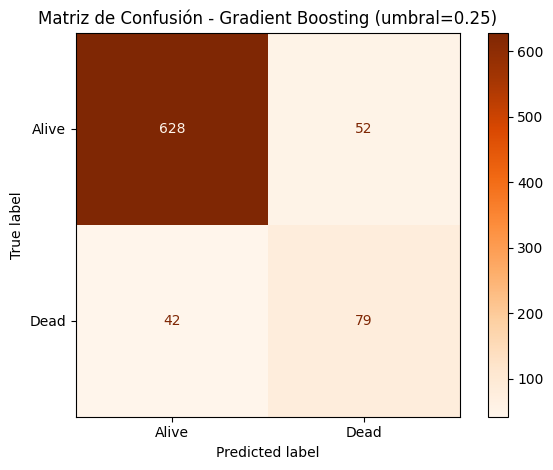

In [17]:
cm_gb = confusion_matrix(y_test, y_pred_gb)
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=['Alive', 'Dead'])
disp_gb.plot(cmap='Oranges')
plt.title(f'Matriz de Confusión - Gradient Boosting (umbral={umbral_optimo})')
plt.tight_layout()
plt.show()

In [18]:
print(f"Reporte de clasificación - Gradient Boosting (umbral={umbral_optimo}):")
print(classification_report(y_test, y_pred_gb, target_names=['Alive', 'Dead']))

Reporte de clasificación - Gradient Boosting (umbral=0.25):
              precision    recall  f1-score   support

       Alive       0.94      0.92      0.93       680
        Dead       0.60      0.65      0.63       121

    accuracy                           0.88       801
   macro avg       0.77      0.79      0.78       801
weighted avg       0.89      0.88      0.88       801



In [19]:
feature_names = cat_cols + num_cols
importancias_gb = best_gb_pipeline.named_steps['clf'].feature_importances_

df_importancias_gb = (
    pd.DataFrame({'Característica': feature_names, 'Importancia': importancias_gb})
    .sort_values('Importancia', ascending=False)
    .reset_index(drop=True)
)

print("Importancia relativa de características - Gradient Boosting:")
display(df_importancias_gb)

Importancia relativa de características - Gradient Boosting:


,Característica,Importancia
0,Survival Months,0.654446
1,Age,0.088046
2,Reginol Node Positive,0.068330
3,Tumor Size,0.043479
4,Regional Node Examined,0.036262
5,Progesterone Status,0.022984
6,6th Stage,0.016799
7,Grade,0.015516
8,Marital Status,0.011440
9,N Stage,0.011361


# Condiciones de entrega de la evaluación:

- Debe entregar un archivo en formato .ipynb. No se admiten URLs.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura (código redundante, funciones innecesarias, versiones preliminares de modelos). Solo entregue el código que de respuesta a lo que se le pide que haga.